## 1. Import libraries

In [7]:
import numpy as np
import time
import matplotlib.pyplot as plt
from numba import cuda
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32
import cupy as cp

## 2. CUDA realization

In [8]:
@cuda.jit
def kernel_evaluate_fitness(population, points_x, points_y, fitnesses, n_params, n_points):
    
    idx = cuda.grid(1)
    if idx >= population.shape[0]:
        return

    total_error = 0.0
    for point in range(n_points):
        x = points_x[point]
        y_true = points_y[point]

        y_approx = 0.0
        x_power = 1.0
        for i in range(n_params):
            y_approx += population[idx, i] * x_power
            x_power *= x

        diff = y_approx - y_true
        total_error += diff * diff

    fitnesses[idx] = total_error
    
@cuda.jit
def kernel_crossover(parents, children, rng_states, population_size, n_params):

    idx = cuda.grid(1)
    if idx >= population_size:
        return

    half = population_size // 2

    r1 = xoroshiro128p_uniform_float32(rng_states, idx)
    r2 = xoroshiro128p_uniform_float32(rng_states, idx)
    r_cross = xoroshiro128p_uniform_float32(rng_states, idx)
    
    p1_idx = int(r1 * half) % half
    p2_idx = int(r2 * half) % half
    cross_point = int(r_cross * (n_params - 1) + 1)

    for gene in range(n_params):
        if gene < cross_point:
            children[idx, gene] = parents[p1_idx, gene]
        else:
            children[idx, gene] = parents[p2_idx, gene]

@cuda.jit
def kernel_mutation(population, rng_states, mutation_rate, mutation_scale, elite_count):

    idx = cuda.grid(1)
    total_genes = (population.shape[0] - elite_count) * population.shape[1]
    if idx >= total_genes:
        return

    ind_idx = elite_count + idx // population.shape[1]
    gene_idx = idx % population.shape[1]

    r = xoroshiro128p_uniform_float32(rng_states, idx)

    if r < mutation_rate:
        delta = xoroshiro128p_uniform_float32(rng_states, idx) * 2 - 1
        population[ind_idx, gene_idx] += delta * mutation_scale
    

## 3. Genethic Algorithm

In [12]:
class GeneticAlgorithmCUDA:

    def __init__(self):
        self._check_cuda()

    # Fitting function
    def fit(
        self,
        points_x,
        points_y,
        pop_size=1200,
        poly_degree=4,
        max_iter=400,
        max_const_iter=80,
        mutation_rate=0.02,
        mutation_scale=0.3,
        elite_fraction=0.05,
        init_range=5.0,
        target_fitness=1e-2,
        threads_per_block=128,
        print_results=True
    ):

        # Population initialization
        n_params = poly_degree + 1
        elite_count = max(1, int(pop_size * elite_fraction))
        n_points = len(points_x)

        def blocks(n):
            return (n + threads_per_block - 1) // threads_per_block

        population = np.random.uniform(-init_range, init_range, (pop_size, n_params)).astype(np.float32)

        px = points_x.astype(np.float32)
        py = points_y.astype(np.float32)

        # GPU transfer
        d_population = cuda.to_device(population)
        d_px = cuda.to_device(px)
        d_py = cuda.to_device(py)
        d_fitnesses = cuda.device_array(pop_size, dtype=np.float32)
        d_children = cuda.device_array_like(d_population)
        rng_states = create_xoroshiro128p_states(pop_size * n_params, seed=42)

        # Logs
        best_log = []
        mean_log = []
        best_fitness = np.inf
        best_coeffs = None
        const_count = 0
        last_gen = 0
        total_start = time.perf_counter()

        # The main cycle
        for gen in range(max_iter):

            # GPU fitness
            kernel_evaluate_fitness[blocks(pop_size), threads_per_block](
                d_population, d_px, d_py, d_fitnesses, n_params, n_points
            )
            cuda.synchronize()

            # CPU sorting population by fitness
            fitnesses = cp.asarray(d_fitnesses.copy_to_host())
            population = cp.asarray(d_population.copy_to_host())
            order = cp.argsort(fitnesses)
            fitnesses = fitnesses[order]
            population = population[order]
            d_population = cuda.to_device(cp.asnumpy(population))
            d_fitnesses = cuda.to_device(cp.asnumpy(fitnesses))

            # Update the best coeffs
            current_best = float(fitnesses[0])
            if current_best < best_fitness:
                best_fitness = current_best
                best_coeffs = cp.asnumpy(population[0])
                const_count = 0
            else:
                const_count += 1

            best_log.append(float(best_fitness))
            mean_log.append(float(cp.mean(fitnesses)))
            last_gen = gen + 1

            # Print intermediate values
            if print_results and (gen % 50 == 0 or gen == max_iter - 1):
                print(
                    f"  Generation {gen+1:>4d} | "
                    f"Best: {best_fitness:.6f} | "
                    f"Mean: {cp.mean(fitnesses):.6f}"
                )

            # Algorithm break conditions
            if best_fitness <= target_fitness:
                if print_results:
                    print(f"\n Target accuracy achieved in generation {gen+1}")
                break

            if const_count >= max_const_iter:
                if print_results:
                    print(f"\n Stagnation: {max_const_iter} generations without improvments")
                break

            # Crossover
            cuda.to_device(cp.asnumpy(population), to=d_population)
            #rng = np.random.default_rng()
            #rand_vals = rng.random((pop_size, 2), dtype=np.float32)
            #rand_cross = rng.random(pop_size, dtype=np.float32)
            #d_rv = cuda.to_device(rand_vals)
           # d_rc = cuda.to_device(rand_cross)

            kernel_crossover[blocks(pop_size), threads_per_block](
                d_population, d_children, rng_states, pop_size, n_params
            )
            cuda.synchronize()

            # Mutation
            total_genes = pop_size * n_params
            #rand_mask = rng.random((pop_size, n_params), dtype=np.float32)
            #rand_delta = rng.standard_normal((pop_size, n_params)).astype(np.float32)
            #d_mask = cuda.to_device(rand_mask)
            #d_delta = cuda.to_device(rand_delta)
            current_scale = mutation_rate * (0.995 ** gen)

            kernel_mutation[blocks(pop_size), threads_per_block](
                d_children, rng_states, mutation_rate, current_scale, elite_count
            )
            cuda.synchronize()

            # Elite transfer
            new_pop = d_children.copy_to_host()
            new_pop[:elite_count] = cp.asnumpy(population[:elite_count])
            cuda.to_device(new_pop, to=d_population)

        gpu_time = time.perf_counter() - total_start

        if print_results:
            self._print_results(best_coeffs, best_fitness, last_gen, gpu_time)

        return {
            "best_coeffs":   best_coeffs,
            "best_fitness":  float(best_fitness),
            "n_generations": last_gen,
            "gpu_time_sec":  gpu_time,
            "best_log":      best_log,
            "mean_log":      mean_log,
        }

    # Function of plot results
    def plot_results(self, result, points_x, points_y, true_fn=None, x_range=None):
       
        if x_range is None:
            x_range = (float(points_x.min()), float(points_x.max()))

        x_plot = np.linspace(x_range[0], x_range[1], 500)
        y_pred = np.polyval(result["best_coeffs"][::-1], x_plot)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle("Genetic Algorithm · Polynomial Approximation", fontsize=14, fontweight="bold")

        ax1.scatter(points_x, points_y, s=10, alpha=0.4, color="#4C72B0", label="Data")
        ax1.plot(x_plot, y_pred, color="#DD4949", lw=2, label="The found polynomial")
        if true_fn is not None:
            ax1.plot(x_plot, true_fn(x_plot), "--", color="#2CA02C", lw=1.5, label="True function")
        ax1.set_title("Approximation")
        ax1.set_xlabel("x")
        ax1.set_ylabel("y")
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        gens = range(1, len(result["best_log"]) + 1)
        ax2.semilogy(gens, result["best_log"], color="#DD4949", label="The best fitness")
        ax2.semilogy(gens, result["mean_log"],  color="#4C72B0", alpha=0.6, label="Mean fitness")
        ax2.set_title("Convergence")
        ax2.set_xlabel("Generation")
        ax2.set_ylabel("Fitness")
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # Assistant methods
    @staticmethod
    def _check_cuda():
        try:
            #cuda.detect()
            print('CUDA is available. GPU is found.')
        except Exception as e:
            raise RuntimeError(
                f"GPU hasn't been found: {e}\n"
            ) from e

    @staticmethod
    def _print_results(coeffs, fitness, n_gen, gpu_time):
        print("\n" + "=" * 55)
        print("  GENETIC ALGORITHM RESULTS")
        print("=" * 55)
        print(f"  Generations completed : {n_gen}")
        print(f"  GPU time        : {gpu_time:.4f} сек")
        print(f"  The best fitness      : {fitness:.8f}")
        print(f"\n  Coefficients of a polynomial:")
        for i, c in enumerate(coeffs):
            print(f"    c{i} = {c:+.6f}  (при x^{i})")
        print("=" * 55)

## 4. Preparation

In [10]:
# Function of test data generation
def generate_test_data(true_coeffs, n_points=700, x_min=-5.0, x_max=5.0, noise_std=0.3, seed=42):

    rng = np.random.default_rng(seed)
    x = rng.uniform(x_min, x_max, n_points)
    y = np.polyval(true_coeffs[::-1], x)
    y += rng.normal(0, noise_std, n_points)
        
    return x.astype(np.float32), y.astype(np.float32)

## 5. Run experiment

In [16]:
print("=" * 55)
print("  GENETIC ALGORITHM - POLYNOMIAL APPROXIMATION")
print("=" * 55)

# f(x) = 1.5 - 0.3x + 0.05x^2 - 0.002x^3 + 0.0001x^4
TRUE_COEFFS = np.array([1.5, -0.3, 0.05, -0.002, 0.0001], dtype=np.float32)

print("\nTrue polinomial:")
for i, c in enumerate(TRUE_COEFFS):
        print(f"  c{i} = {c:+.6f}  (at x^{i})")

points_x, points_y = generate_test_data(
    TRUE_COEFFS, n_points=700, x_min=-5.0, x_max=5.0, noise_std=0.1
)

print(f"\nPoints generated: {len(points_x)}")
print("\nRunning the genetic algorithm on GPU...\n")

genetic_algorithm = GeneticAlgorithmCUDA()

result = genetic_algorithm.fit(
        points_x,
        points_y,
        pop_size=2000,
        poly_degree=4,
        max_iter=1000,
        max_const_iter=50,
        mutation_rate=0.05,
        mutation_scale=0.01,
        elite_fraction=0.1,
        init_range=1.0,
        target_fitness=7.0,
        threads_per_block=128,
        print_results=True
)

print(f"\nTime on GPU: {result['gpu_time_sec']:.3f} sec")

  GENETIC ALGORITHM - POLYNOMIAL APPROXIMATION

True polinomial:
  c0 = +1.500000  (at x^0)
  c1 = -0.300000  (at x^1)
  c2 = +0.050000  (at x^2)
  c3 = -0.002000  (at x^3)
  c4 = +0.000100  (at x^4)

Points generated: 700

Running the genetic algorithm on GPU...

CUDA is available. GPU is found.
  Generation    1 | Best: 8355.386719 | Mean: 10126970.000000
  Generation   51 | Best: 74.788857 | Mean: 236.308228
  Generation  101 | Best: 56.303715 | Mean: 162.140518
  Generation  151 | Best: 47.166164 | Mean: 109.418961
  Generation  201 | Best: 31.258596 | Mean: 68.971268
  Generation  251 | Best: 23.397150 | Mean: 49.143810
  Generation  301 | Best: 15.060957 | Mean: 37.658493
  Generation  351 | Best: 12.660645 | Mean: 18.789152
  Generation  401 | Best: 10.890576 | Mean: 13.996461
  Generation  451 | Best: 9.857299 | Mean: 12.262680
  Generation  501 | Best: 8.886943 | Mean: 10.953080
  Generation  551 | Best: 7.962035 | Mean: 9.080711
  Generation  601 | Best: 7.799574 | Mean: 8.18

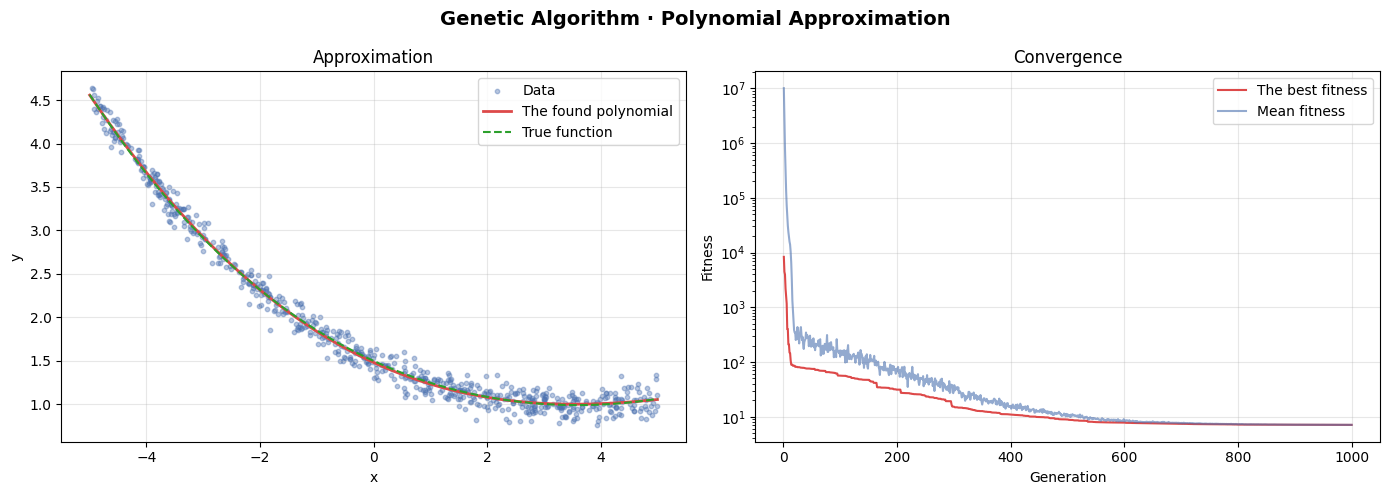

In [17]:
genetic_algorithm.plot_results(
    result, 
    points_x,
    points_y,
    true_fn = lambda x: np.polyval(TRUE_COEFFS[::-1], x),
    x_range = (-5, 5)
)

## Trying to find better parameters...

In [45]:
from IPython.display import clear_output

params = {
    'pop_size': (1000, 1250, 1500, 2000),
    'mutation_rate': (0.02, 0.05, 0.1, 0.2),
    'mutation_scale': (0.02, 0.1, 0.2, 0.3),
    'elite_fraction': (0.02, 0.05, 0.1, 0.2)
}

def find_best(TRUE_COEFFS, params):
    points_x, points_y = generate_test_data(
    TRUE_COEFFS, n_points=700, x_min=-5.0, x_max=5.0, noise_std=0.2
    )

    print(f"\nPoints generated: {len(points_x)}")
    print("\nRunning the genetic algorithm on GPU...\n")

    fits = []
    history_param = []
    count = 0
    all_time = 0.0

    for pop_size in params['pop_size']:
        for mutation_rate in params['mutation_rate']:
            for mutation_scale in params['mutation_scale']:
                for elite_fraction in params['elite_fraction']:

                    clear_output(wait=True)
                    
                    genetic_algorithm = GeneticAlgorithmCUDA()
                    result = genetic_algorithm.fit(
                        points_x,
                        points_y,
                        pop_size=pop_size,
                        poly_degree=4,
                        max_iter=500,
                        max_const_iter=80,
                        mutation_rate=mutation_rate,
                        mutation_scale=mutation_scale,
                        elite_fraction=elite_fraction,
                        init_range=5.0,
                        target_fitness=1e-2,
                        threads_per_block=128,
                        print_results=False
                    )

                    count += 1
                    all_time += result['gpu_time_sec']
                    print(f'{count}/256')
                    print(f'{all_time:.2f} sec.')
                    fits.append(result['best_fitness'])
                    history_param.append([pop_size, mutation_rate, mutation_scale, elite_fraction])

    return fits, history_param

                    
    print(f"\nTime on GPU: {result['gpu_time_sec']:.3f} sec")

In [46]:
fits, history_param = find_best(TRUE_COEFFS, params)

256/256
402.65 sec.


In [49]:
fits = np.array(fits)
history_param = np.array(history_param)

order = np.argsort(fits)
fits = fits[order]
history_param = history_param[order]

print(fits[:10])
print(history_param[:10])

[28.24118996 28.24233818 28.24267006 28.24901772 28.25091743 28.25304985
 28.25413322 28.2555027  28.26186562 28.26535606]
[[1.50e+03 1.00e-01 2.00e-02 5.00e-02]
 [2.00e+03 1.00e-01 2.00e-02 5.00e-02]
 [2.00e+03 2.00e-01 2.00e-02 1.00e-01]
 [2.00e+03 2.00e-01 2.00e-02 5.00e-02]
 [1.00e+03 2.00e-01 2.00e-02 5.00e-02]
 [1.25e+03 2.00e-01 2.00e-02 5.00e-02]
 [2.00e+03 5.00e-02 2.00e-02 2.00e-02]
 [1.00e+03 2.00e-01 2.00e-02 2.00e-02]
 [1.00e+03 5.00e-02 2.00e-02 2.00e-01]
 [2.00e+03 5.00e-02 2.00e-02 2.00e-01]]
